# **Evaluate MobileNetV2**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

In [2]:
# Set paths
model_path = '../models/smart_bin_model.h5'
test_dir = '../dataset_split/test'
results_dir = '../results'
os.makedirs(results_dir, exist_ok=True)

img_size = (224, 224)
batch_size = 32
classes = ['biological', 'plastic']

In [3]:
# Load Model and Test data
model = load_model(model_path)

# Load test images 
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'binary',
    classes = classes,
    shuffle = False
)

Found 314 images belonging to 2 classes.


In [4]:
print(test_gen.samples)
print(test_gen.class_indices)

314
{'biological': 0, 'plastic': 1}


In [5]:
# Get Predictions
# Get predicted probabilities
y_prob = model.predict(test_gen, verbose=1)

# Convert probability to class (0 = biological, 1 = plastic)
y_pred = (y_prob > 0.5).astype(int).flatten()

# True labels
y_true = test_gen.classes

print(f'   Total test images : {len(y_true)}')
print(f'   Correct           : {np.sum(y_pred == y_true)}')
print(f'   Wrong             : {np.sum(y_pred != y_true)}')

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 328ms/step
   Total test images : 314
   Correct           : 311
   Wrong             : 3


In [6]:
# Test accuracy & Loss
test_loss, test_acc = model.evaluate(test_gen, verbose=0)

print('='*48)
print('     TEST RESULTS — MobileNetV2')
print('='*48)
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Test Loss     : {test_loss:.4f}')
print('='*48)

     TEST RESULTS — MobileNetV2
  Test Accuracy : 99.04%
  Test Loss     : 0.0373


In [7]:
# Classification report
print('CLASSIFICATION REPORT')
print('='*55)
print(classification_report(
    y_true, y_pred,
    target_names=classes
))
print('='*55)
print('Precision = out of all predicted plastic, how many were really plastic')
print('Recall    = out of all real plastic images, how many did model catch')
print('F1-Score  = balance between precision and recall (higher = better)')

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  biological       0.99      0.99      0.99       157
     plastic       0.99      0.99      0.99       157

    accuracy                           0.99       314
   macro avg       0.99      0.99      0.99       314
weighted avg       0.99      0.99      0.99       314

Precision = out of all predicted plastic, how many were really plastic
Recall    = out of all real plastic images, how many did model catch
F1-Score  = balance between precision and recall (higher = better)


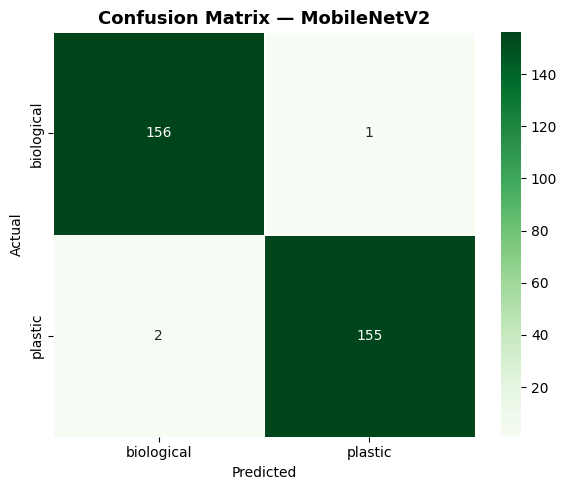

In [8]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Greens',
    xticklabels= classes,
    yticklabels= classes,
    linewidths = 0.5
)
ax.set_title('Confusion Matrix — MobileNetV2', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'confusion_matrix.png'),
            dpi=150, bbox_inches='tight')
plt.show()

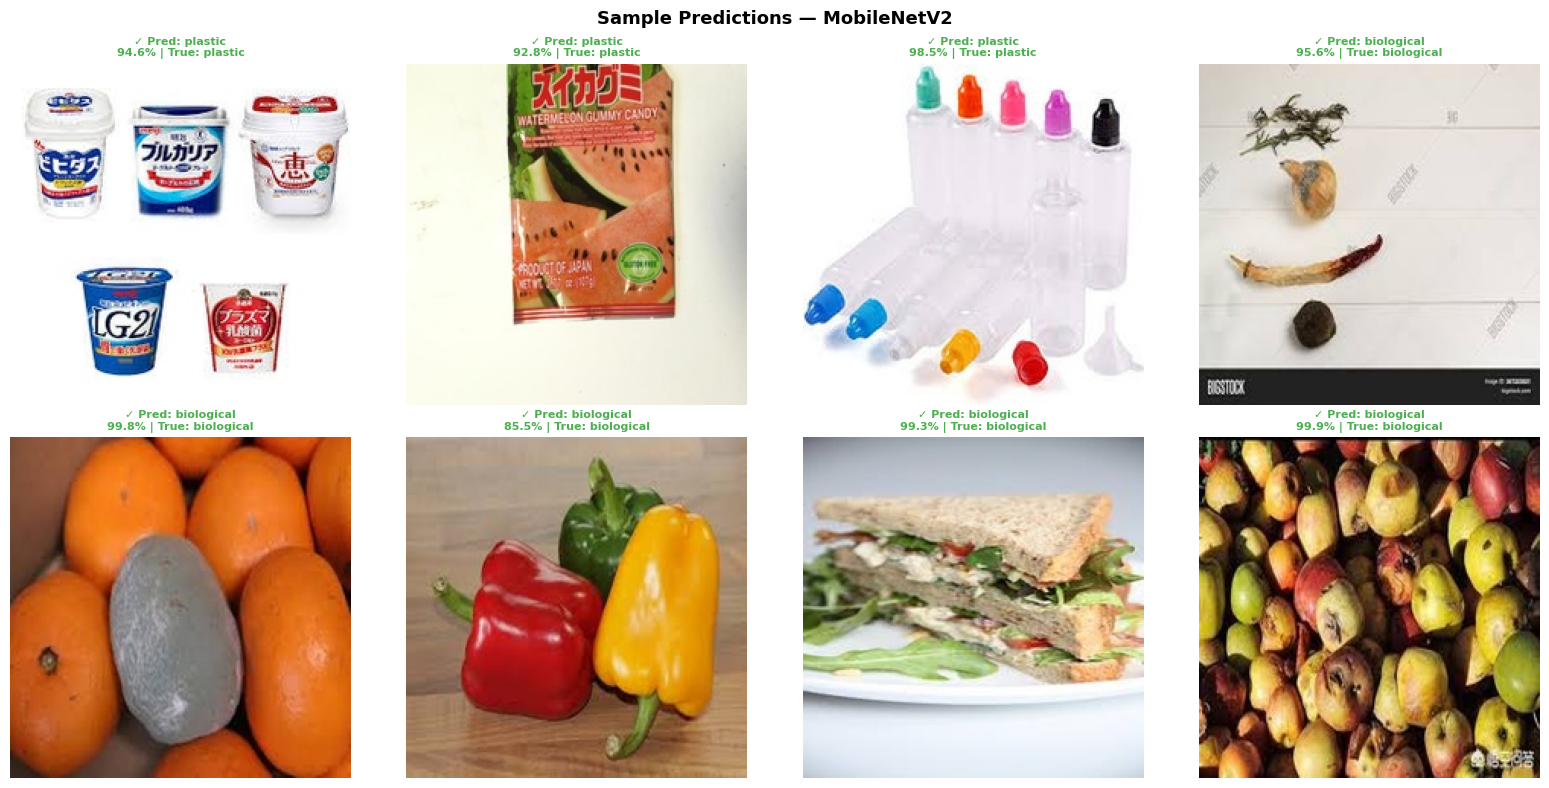

In [9]:
# Sample Predicitons with images
import random
from PIL import Image as PILImage

# Get all test image paths
all_paths = []
for cls in classes:
    cls_dir = os.path.join(test_dir, cls)
    for f in os.listdir(cls_dir):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_paths.append((os.path.join(cls_dir, f), cls))

random.seed(40)
samples = random.sample(all_paths, min(8, len(all_paths)))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Predictions — MobileNetV2',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, (path, true_label) in enumerate(samples):
    # Load and preprocess image
    img     = PILImage.open(path).convert('RGB').resize(img_size)
    img_arr = np.array(img) / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)

    # Predict
    prob        = model.predict(img_arr, verbose=0)[0][0]
    pred_label  = 'plastic' if prob > 0.5 else 'biological'
    confidence  = prob * 100 if prob > 0.5 else (1 - prob) * 100
    is_correct  = pred_label == true_label

    # Show image
    axes[i].imshow(img)
    axes[i].axis('off')
    color = '#4CAF50' if is_correct else '#F44336'
    status = '✓' if is_correct else '✗'
    axes[i].set_title(
        f'{status} Pred: {pred_label}\n{confidence:.1f}% | True: {true_label}',
        color=color, fontsize=8, fontweight='bold'
    )

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'sample_predictions.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)

print('='*50)
print('   EVALUATION SUMMARY — MobileNetV2')
print('='*50)
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Precision     : {precision*100:.2f}%')
print(f'  Recall        : {recall*100:.2f}%')
print(f'  F1-Score      : {f1*100:.2f}%')
print('='*50)

   EVALUATION SUMMARY — MobileNetV2
  Test Accuracy : 99.04%
  Test Loss     : 0.0373
  Precision     : 99.36%
  Recall        : 98.73%
  F1-Score      : 99.04%
